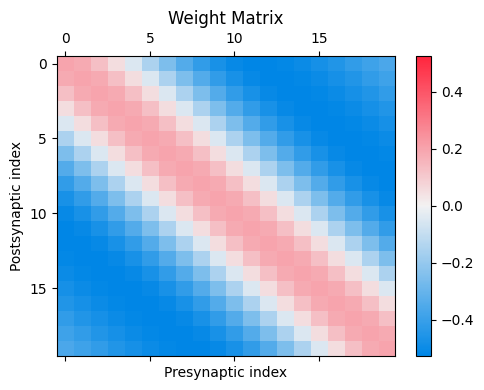

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import TwoSlopeNorm

# --------------------
# Parameters
# --------------------
N = 20                  # number of neurons along the line
dx = 1.0                # spacing
sigma_e = 5.0           # excitatory width
sigma_i = 15.0          # inhibitory width
A = 1.0                 # excitatory strength
B = 0.8                 # inhibitory strength

# --------------------
# Spatial coordinates
# --------------------
x = np.arange(N) * dx
x = x - x.mean()        # center at zero

# --------------------
# Difference of Gaussians kernel
# --------------------
def gaussian(x, sigma):
    return np.exp(-x**2 / (2 * sigma**2))

W = np.zeros((N, N))
for i in range(N):
    for j in range(N):
        d = i - j
        W[i, j] = (
            A * np.exp(-d**2 / (2 * sigma_e**2))
            - B * np.exp(-d**2 / (2 * sigma_i**2))
        )

# --------------------
# Plot
# --------------------
fig, axs = plt.subplots(1, 1, figsize=(5, 4))

cmap = sns.diverging_palette(250, 10, s=100, l=55, as_cmap=True)

# Use TwoSlopeNorm to ensure white maps to 0
v = np.abs(W).max()
norm = TwoSlopeNorm(vmin=-v, vcenter=0, vmax=v)

# Weight matrix
im = axs.matshow(W, aspect="auto", norm=norm, cmap=cmap)
axs.set_title("Weight Matrix")
axs.set_xlabel("Presynaptic index")
axs.set_ylabel("Postsynaptic index")
plt.colorbar(im, ax=axs)

plt.tight_layout()
plt.show()